In [15]:
import sys
path = "../../.."
if path not in sys.path:
    sys.path.insert(0, path)

In [16]:
from data_retrieval import lipade_groundtruth
from absolute_path import absolutePath
from transformers import CLIPModel, CLIPProcessor
from PIL import Image
import numpy as np
from torchvision import transforms
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt
import os

root = "" # os.environ['DSDIR'] + '/HuggingFace_Models/'
#device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")

corpus = "lipade_groundtruth"
distancePath = "../results/distance/" + corpus + "/"
rawPath = "../results/raw/" + corpus + "/"
weightsPath = "../results/weights/" + corpus + "/"
model_save_path = "clip.pth"
batch_size = 32

In [17]:
# Model
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model = CLIPModel.from_pretrained(root + "openai/clip-vit-base-patch32").to(device)
torch.save(model.state_dict(), weightsPath + f"pretrained_{model_save_path}")

# Images
x,m,_ = lipade_groundtruth.getDataset(mode="unique")
is_recto = np.array(m[2])
x = np.array(x)[is_recto]

# Captions
captions = m[1]
images_per_captions = {}
images = []
for file,prompt in captions.keys():
    images_per_captions[prompt] = []

for i in range(len(x)):
    f = '/'.join(x[i].split('/')[-2:])
    if (f, prompt) not in captions.keys():
        images.append(x[i])

x = x.tolist()
for im in images:
    x.remove(im)

for prompt in images_per_captions.keys():
    for i in range(len(x)):
        f = '/'.join(x[i].split('/')[-2:])
        images_per_captions[prompt].append(captions[(f, prompt)])

In [18]:
class CustomDataset(Dataset):
    def __init__(self, image_paths, captions):
        self.image_paths = image_paths
        self.captions = captions

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        return self.image_paths[idx], self.captions[idx], idx

In [19]:
def semantic_matching_loss(image_embeds, text_embeds, M, tau=0.07):
    image_embeds = F.normalize(image_embeds, dim=-1)
    text_embeds = F.normalize(text_embeds, dim=-1)

    logits = (image_embeds @ text_embeds.T) / tau
    pred_probs = F.log_softmax(logits, dim=-1)

    target_probs = F.softmax(M.to(device), dim=-1)
    loss = -torch.sum(target_probs * pred_probs) / image_embeds.size(0)
    return loss

In [20]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-6)

# Caption 1 - "a black and white photo of "

In [21]:
captions = images_per_captions["a black and white photo of "]

train_images, val_images, train_captions, val_captions = train_test_split(
    x, captions, test_size=0.1, random_state=42
)

train_loader = DataLoader(CustomDataset(train_images, train_captions), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(CustomDataset(val_images, val_captions), batch_size=batch_size, shuffle=False)

In [22]:
def evaluate_model(model, val_loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for paths, captions, indices in val_loader:
            images = []
            for path in paths:
                image = Image.open(path).convert("RGB")
                images.append(image)
            captions = list(captions)
            inputs = processor(text=captions, images=images, return_tensors="pt", padding=True, truncation=True)
            inputs = inputs.to(device)
            outputs = model(**inputs)
            image_embeds = outputs.image_embeds
            text_embeds = outputs.text_embeds

            M = torch.eye(len(indices)).float() # Similarity matrix
            
            loss = semantic_matching_loss(image_embeds, text_embeds, M)
            total_loss += loss.item()

    avg_loss = total_loss / len(val_loader)
    return avg_loss

1: 100%|██████████| 145/145 [20:32<00:00,  8.50s/it]


[Epoch 0, Step 145] Train Loss: 3.2816, Val Loss: 3.3134


2: 100%|██████████| 145/145 [22:44<00:00,  9.41s/it]


[Epoch 1, Step 290] Train Loss: 3.2836, Val Loss: 3.3116


3: 100%|██████████| 145/145 [06:21<00:00,  2.63s/it]


[Epoch 2, Step 435] Train Loss: 3.2806, Val Loss: 3.3111


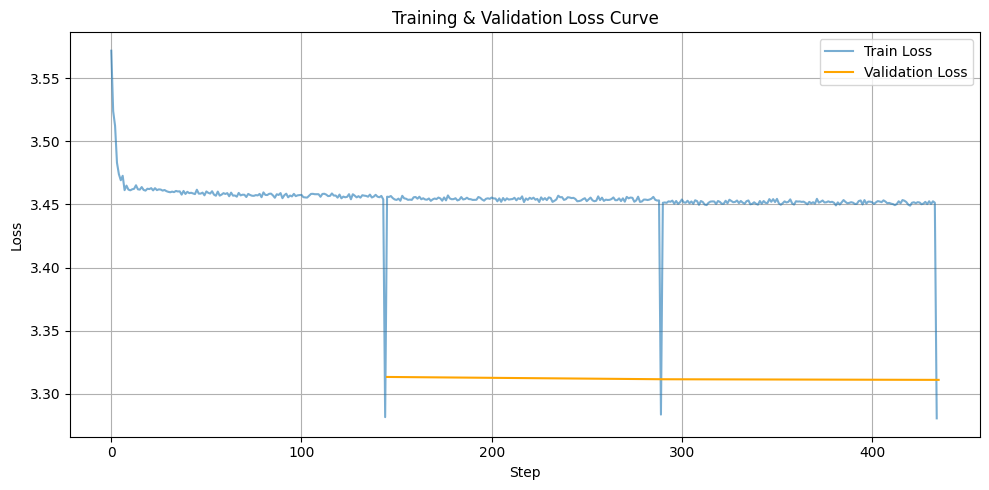

In [23]:
train_losses = []
val_losses = []
train_steps = []
val_steps = []
global_step = 0
eval_interval = 25
num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    for batch_id, (paths, captions, indices) in enumerate(tqdm(train_loader, desc=str(epoch+1))):
        images = []
        for path in paths:
            image = Image.open(path).convert("RGB")
            images.append(image)
        captions = list(captions)
        inputs = processor(text=captions, images=images, return_tensors="pt", padding=True, truncation=True)
        inputs = inputs.to(device)
        outputs = model(**inputs)
        image_embeds = outputs.image_embeds
        text_embeds = outputs.text_embeds

        M = torch.eye(len(indices)).float() # Similarity matrix

        loss = semantic_matching_loss(image_embeds, text_embeds, M)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        train_losses.append(loss.item())
        train_steps.append(global_step)
        global_step += 1

    torch.save(model.state_dict(), weightsPath + f"c1_e{epoch}_{model_save_path}")
    val_loss = evaluate_model(model, val_loader)
    val_losses.append(val_loss)
    val_steps.append(global_step)
    print(f"[Epoch {epoch}, Step {global_step}] Train Loss: {loss.item():.4f}, Val Loss: {val_loss:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_losses, label='Train Loss', alpha=0.6)
plt.plot(val_steps, val_losses, label='Validation Loss', color='orange')
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training & Validation Loss Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
from sklearn.metrics.pairwise import cosine_similarity
import clustering.evaluators as evaluators
from data_retrieval.tools.data_loader import getDataLoader

resultsPath = "/home/renard/HighVision_moi/representation/multimodal/results/distance/" + corpus + "/"


# Test
xSim,_,ySim = lipade_groundtruth.getDataset(mode = 'similar', uniform=True)
_,_,y_test = lipade_groundtruth.getDataset(mode="similar")

imagesSim = []
for i in range(len(xSim)):
    try:
        imagesSim.append(Image.open(xSim[i]).convert('RGB'))
    except:
        print("Error loading image:", xSim[i])

trans_re = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor()])
testLoader = getDataLoader(imagesSim, None, trans_re, False, batch_size, shuffle=False, num_workers=2)

def test(clip_model, name, testLoader, y_test):
    # Test 
    representations = []
    with torch.no_grad():
        for batch in testLoader:
            batch = clip_model.get_image_features(pixel_values=batch) #.to(device))
            for repr in batch.tolist():
                representations.append(repr)
    
    sim = cosine_similarity(representations, representations)

    distance = 1 - (sim+1)/2
    distance -= np.diag(distance)

    np.save(resultsPath + f"slip_{name}.npy", distance)

    method = f"slip_{name}"

    thresholds_precision = 1000
    thresholds = np.linspace(0, 1, thresholds_precision)

    precisions, recalls, f1s = evaluators.p_r_f1_byThresholds(thresholds, distance, y_test)
    f1 = np.max(f1s)
    AP, bestThresholdIndex = evaluators.pr_curve(precisions, recalls, f1s, other=("Fei mAP", evaluators.fei_mAP(y_test, distance)), save="/home/renard/HighVision_moi/clustering/evaluation/" + corpus + "/" + method + ".png")

    thresholdsClass = np.linspace(0, 1, int(thresholds_precision / 10))
    precisions_per_class, recalls_per_class = evaluators.p_r_class_byThresholds(thresholdsClass, distance, y_test)
    fei = evaluators.fei_mAP(y_test, distance)
    sam = evaluators.goncalves_mAP(precisions_per_class, recalls_per_class)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Thresholds: 100%|██████████|

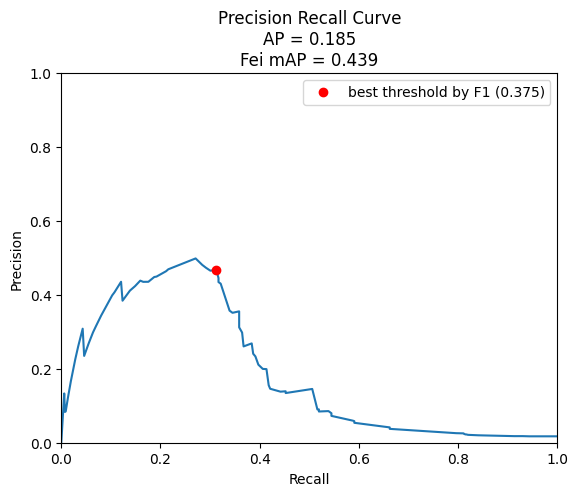

In [31]:
test(model, 'clip_my_test', testLoader, y_test)


In [10]:
# TODO : Train the model to have [1, 0, 0, ...] for the first image, [0, 1, 0, ...] for the second image, etc. => Matrice de similarite ???
# https://www.marqo.ai/course/fine-tuning-clip-models
# https://huggingface.co/openai/clip-vit-base-patch32

## 1.1) Train

# Caption 2 - "a newspaper clipping from the early 1900s showing "

In [11]:
captions = images_per_captions["a newspaper clipping from the early 1900s showing "]

## 1.1) Train

# Captions 1&2